<a href="https://colab.research.google.com/github/LucasCabra7/precos-combustiveis-brasil-2015-2025/blob/main/Grupo_4_An%C3%A1lise_Explorat%C3%B3ria_e_Modelagem_Preditiva_dos_Pre%C3%A7os_de_Combust%C3%ADveis_no_Brasil_(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória e Modelagem Preditiva dos Preços de Combustíveis no Brasil (2015–2025)



# 1. Descrição do Dataset e do Projeto

O Projeto tem como objetivo analisar e compreender o comportamento dos preços de combustíveis no Brasil ao longo do tempo, utilizando dados públicos disponibilizados pela [Agência Nacional do Petróleo, Gás Natural e Biocombustíveis](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis).

O conjunto de dados utilizado consiste na série histórica de preços de combustíveis, com informações coletadas semanalmente em diversos postos distribuídos por estados e municípios brasileiros. A base contempla variáveis relevantes, como localização geográfica (estado e município), região, tipo de combustível, datas de coleta e valores de compra e venda.

As **regiões brasileiras** consideradas na base são:

* Norte (N)
* Nordeste (NE)
* Sudeste (SE)
* Sul (S)
* Centro-Oeste (CO)

Já os **produtos analisados** incluem:

* Gasolina Comum
* Gasolina Aditivada
* Etanol
* Diesel
* Diesel S10
* GNV (Gás Natural Veicular)

Para este estudo, foi selecionado o **período de 2015 a 2025**, por apresentar maior consistência nos dados e abranger eventos econômicos relevantes que impactaram diretamente os preços dos combustíveis, tais como:

* 2016 – Crise econômica no Brasil
* 2018 – Greve dos caminhoneiros (impacto direto no abastecimento)
* 2020 – Pandemia de COVID-19
* 2022 – Alta global dos combustíveis

O conjunto de dados consolidado possui 9.889.848 instâncias (linhas) e 17 atributos (colunas), incluindo variáveis categóricas (como estado, município, produto e bandeira), numéricas contínuas (como valores de compra e venda) e temporais (datas de coleta).

Do ponto de vista analítico, este projeto também investiga a relação entre os preços de venda dos combustíveis ao longo dos anos e o poder de compra da população brasileira, representado pelo **IPCA (Índice Nacional de Preços ao Consumidor Amplo)**, calculado pelo [Banco Central do Brasil](https://www.bcb.gov.br/controleinflacao/historicometas).

O objetivo é verificar a existência de correlação entre a evolução dos preços dos combustíveis e a inflação oficial do país, buscando compreender se os aumentos nos preços acompanham, superam ou divergem da variação inflacionária no período analisado. A análise de correlação permite identificar o grau de associação entre essas variáveis, podendo indicar relações positivas, negativas ou inexistentes.

Ressalta-se que correlação não implica causalidade, ou seja, mesmo que haja associação entre as variáveis, não é possível afirmar que uma seja a causa direta da outra. Ainda assim, essa análise contribui para uma compreensão mais aprofundada do comportamento dos preços dos combustíveis no contexto econômico nacional e seus impactos sobre o poder de compra da população.

Por fim, sob a perspectiva de ciência de dados, o estudo configura-se como um problema de regressão e classificação, tendo como objetivo futuro a previsão dos preços dos combustíveis e a categorização de tendências de mercado (alta, baixa ou estabilidade). Essas aplicações possuem relevância prática, como o apoio à tomada de decisão no setor de transporte e o monitoramento de anomalias no mercado.



# 2. Estruturação do Projeto

#### 2.1. Importações

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import data as cp
from IPython.display import display

#### 2.2. Caminho para o Dataset e correções

In [46]:
class CarregadorDeDataset:
    def __init__(self, caminho_do_arquivo: str):
        self.caminho_do_arquivo = caminho_do_arquivo

    def carregar_dados_brutos(self) -> pd.DataFrame:
        print("Carregando o dataset completo.... Aguarde!")
        dataframe_bruto = pd.read_csv(self.caminho_do_arquivo, sep=';', low_memory=False)
        print(f"Dataset carregado com sucesso! Total de linhas: {len(dataframe_bruto)}")
        return dataframe_bruto


class FormatadorDeDados:
    def converter_valor_de_venda_de_texto_para_decimal(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        dataframe['Valor de Venda'] = dataframe['Valor de Venda'].str.replace(',', '.').astype(float)
        return dataframe


class PipelineDePreparacaoDeDados:
    def __init__(self, carregador: CarregadorDeDataset, formatador: FormatadorDeDados):
        self.carregador = carregador
        self.formatador = formatador

    def executar_preparacao(self) -> pd.DataFrame:
        dados_brutos = self.carregador.carregar_dados_brutos()
        dados_formatados = self.formatador.converter_valor_de_venda_de_texto_para_decimal(dados_brutos)
        return dados_formatados

# Execução
caminho_dataset = 'data/Dataset_Completo_2015_2025.csv'

carregador_csv = CarregadorDeDataset(caminho_dataset)
formatador_de_colunas = FormatadorDeDados()

pipeline_preparacao = PipelineDePreparacaoDeDados(carregador_csv, formatador_de_colunas)
dataframe_final = pipeline_preparacao.executar_preparacao()

Carregando o dataset completo.... Aguarde!
Dataset carregado com sucesso! Total de linhas: 9889848


# 3. Análises Estatísticas Descritivas





## 3.1.0 Análise Exploratória Inicial do Dataset

A análise exploratória inicial foi realizada com o objetivo de compreender a estrutura e os principais elementos da base de dados utilizada no estudo.

O dataset apresenta informações relacionadas à comercialização de combustíveis no Brasil no período de 2015 a 2025, permitindo uma visão abrangente da dinâmica de preços e distribuição ao longo do tempo e do território nacional.

Entre as variáveis analisadas, destacam-se:

* Produto: identifica o tipo de combustível comercializado, sendo os principais gasolina, etanol, diesel e GNV;
* Município e Região: possibilitam a análise geográfica dos dados, evidenciando a distribuição espacial das observações;
* Unidade de Medida: associada ao tipo de combustível, indicando a forma de comercialização (por exemplo, litros ou metros cúbicos);
* Bandeira: representa a marca ou distribuidora vinculada ao posto de combustíveis.


In [47]:
class AnalisadorExploratorio:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def exibir_dimensoes_do_dataset(self):
        print("ANÁLISE EXPLORATÓRIA - VISÃO GERAL")
        print(f"Dimensões do dataset: ")
        print(f"Total de linhas: {self.dataframe.shape[0]}")
        print(f"Total de colunas: {self.dataframe.shape[1]}")

    def exibir_contagem_de_produtos(self):
        print("\n CONTAGEM DE PRODUTOS:")
        display(self.dataframe['Produto'].value_counts())

    def calcular_e_exibir_municipios_unicos_por_regiao(self):
        print("\n MUNICÍPIOS POR REGIÃO:")
        municipios_por_regiao = ( 
            self.dataframe[['Municipio', 'Regiao - Sigla']]
            .drop_duplicates()
            .value_counts('Regiao - Sigla')
        )
        display(municipios_por_regiao)

    def extrair_e_exibir_unidades_de_medidas_produtos(self):
        print("\n UNIDADES DE MEDIDA POR PRODUTO:")
        unidades_por_produto = (
            self.dataframe[['Produto', 'Unidade de Medida']]
            .drop_duplicates()
            .sort_values(by='Produto')
        )
        display(unidades_por_produto)
        
    def exibir_bandeiras_mais_frequentes(self):
        print("\n BANDEIRAS MAIS FREQUENTES:")
        bandeiras_mais_frequentes = self.dataframe['Bandeira'].value_counts().head(10)
        display(bandeiras_mais_frequentes)
        
    def gerar_relatorio_completo_visao_geral(self):
        self.exibir_dimensoes_do_dataset()
        print(" ")
        self.exibir_contagem_de_produtos()
        print(" ")
        self.calcular_e_exibir_municipios_unicos_por_regiao()
        print(" ")
        self.extrair_e_exibir_unidades_de_medidas_produtos()
        print(" ")
        self.exibir_bandeiras_mais_frequentes()
        
analisador = AnalisadorExploratorio(dataframe_final)
analisador.gerar_relatorio_completo_visao_geral()

ANÁLISE EXPLORATÓRIA - VISÃO GERAL
Dimensões do dataset: 
Total de linhas: 9889848
Total de colunas: 16
 

 CONTAGEM DE PRODUTOS:


Produto
GASOLINA              2804451
ETANOL                2476383
DIESEL S10            2074854
DIESEL                1475800
GASOLINA ADITIVADA     867576
GNV                    181670
Name: count, dtype: int64

 

 MUNICÍPIOS POR REGIÃO:


Regiao - Sigla
SE    244
NE    144
S     117
N      61
CO     38
Name: count, dtype: int64

 

 UNIDADES DE MEDIDA POR PRODUTO:


,Produto,Unidade de Medida
2,DIESEL,R$ / litro
4,DIESEL S10,R$ / litro
1,ETANOL,R$ / litro
0,GASOLINA,R$ / litro
3,GASOLINA ADITIVADA,R$ / litro
82,GNV,R$ / m³
3515037,GNV,R$ / m3
3130447,NaN,NaN


 

 BANDEIRAS MAIS FREQUENTES:


Bandeira
BRANCA                          3239682
IPIRANGA                        1833952
RAIZEN                          1507744
PETROBRAS DISTRIBUIDORA S.A.    1459621
VIBRA ENERGIA                    453895
VIBRA                            452995
ALESAT                           237661
SABBÁ                            107301
ATEM' S                           43520
SP                                42369
Name: count, dtype: int64

## 3.2.0 Análises Bivariadas por Meio de Estatísticas Descritivas Agrupadas

A realização de análises bivariadas, por meio de estatísticas descritivas agrupadas sobre os dados brutos, permite compreender as relações existentes entre pares de variáveis.

A partir do agrupamento dos dados e do cálculo de medidas como a média dos preços por região ou município, é possível identificar diferenças relevantes entre localidades. Essa abordagem possibilita a observação de padrões geográficos e contribui para o entendimento de como fatores regionais podem influenciar os preços dos combustíveis.

#### 3.2.1. Estatísticas Descritivas Brutas por Regiões Brasileiras

Nesta etapa, foram analisadas as frequências absoluta (número de ocorrências) e relativa (percentual) das regiões brasileiras presentes no dataset, considerando o período de 2015 a 2025.

O principal objetivo dessa análise é identificar quais regiões possuem maior representatividade na base de dados, permitindo avaliar a existência de possíveis desequilíbrios amostrais (desbalanceamento de classes) entre as regiões.

Esse tipo de investigação é fundamental, uma vez que a predominância de determinadas regiões pode influenciar diretamente os resultados e as interpretações das análises subsequentes, podendo introduzir vieses nas conclusões obtidas.

In [48]:

class AnalisadorDistribuidorRegional:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        
    def calcular_exbir_frequencia_absoluta_regional(self):
        print("\nFREQUÊNCIA ABSOLUTA REGIONAL:")
        frequencia_absoluta_por_regiao = (
            self.dataframe['Regiao - Sigla']
            .value_counts()
            .reset_index()
            )
        frequencia_absoluta_por_regiao.columns = ['Região', 'Quantidade de Registros']
        frequencia_absoluta_por_regiao.set_index('Região', inplace=True)
        display(frequencia_absoluta_por_regiao)
        
    def calcular_exibir_frequencia_percentual_regional(self):
        print("\nFREQUÊNCIA PERCENTUAL REGIONAL:")
        frequencia_percentual_por_regiao = (
            self.dataframe['Regiao - Sigla']
            .value_counts(normalize=True)
            .round(4)* 100
            ).reset_index()
        
        frequencia_percentual_por_regiao.columns = ['Região', 'Percentual (%)']
        frequencia_percentual_por_regiao.set_index('Região', inplace=True)
        display(frequencia_percentual_por_regiao)
        
    def gerar_relatorio_completo_distribuidor_regional(self):
        self.calcular_exbir_frequencia_absoluta_regional()
        print(" ")
        self.calcular_exibir_frequencia_percentual_regional()
        
analisador_regional = AnalisadorDistribuidorRegional(dataframe_final)
analisador_regional.gerar_relatorio_completo_distribuidor_regional()


FREQUÊNCIA ABSOLUTA REGIONAL:


,Quantidade de Registros
Região,
SE,4805520
NE,1948525
S,1671048
CO,842951
N,612690


 

FREQUÊNCIA PERCENTUAL REGIONAL:


,Percentual (%)
Região,
SE,48.64
NE,19.72
S,16.91
CO,8.53
N,6.20


#### 3.2.2 Estatísticas Descritivas Brutas das Regiões Brasileiras por Produto

Nesta etapa, foram analisadas as frequências absoluta (número de ocorrências) e relativa (percentual) das regiões brasileiras em relação aos diferentes tipos de combustível (produto) presentes no dataset, considerando o período de 2015 a 2025.

O objetivo dessa análise é identificar quais regiões apresentam maior representatividade para cada tipo de produto na base de dados, permitindo avaliar a existência de possíveis desequilíbrios amostrais (desbalanceamento de classes) entre regiões e combustíveis.



In [49]:
class AnalisadorDistribuicaoProdutoPorRegiao:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        
    def calcular_exibir_frequencia_absoluta_produto_por_regiao(self):
        print("\nFREQUÊNCIA ABSOLUTA DE PRODUTOS POR REGIÃO:")
        frequencia_absoluta_produto_por_regiao = (
            self.dataframe
            .groupby(['Produto', 'Regiao - Sigla'])
            .size()
            .unstack(fill_value=0)
            )
        display(frequencia_absoluta_produto_por_regiao)
        
    def calcular_exibir_frequencia_percentual_produto_por_regiao(self):
        print("\nFREQUÊNCIA PERCENTUAL DE PRODUTOS POR REGIÃO:")
        frequencia_percentual_produto_por_regiao = (
            self.dataframe
            .groupby(['Produto', 'Regiao - Sigla'])
            .size()
            .unstack(fill_value=0)
            .apply(lambda x: (x / x.sum()) * 100, axis=1)
            .round(4)
            )
        display(frequencia_percentual_produto_por_regiao)
        
analisador_produto_por_regiao = AnalisadorDistribuicaoProdutoPorRegiao(dataframe_final)
analisador_produto_por_regiao.calcular_exibir_frequencia_absoluta_produto_por_regiao()
print(" ")
analisador_produto_por_regiao.calcular_exibir_frequencia_percentual_produto_por_regiao()


FREQUÊNCIA ABSOLUTA DE PRODUTOS POR REGIÃO:


Regiao - Sigla,CO,N,NE,S,SE
Produto,,,,,
DIESEL,147727,127832,250991,268079,681171
DIESEL S10,167006,148752,454854,364531,939711
ETANOL,230593,91795,479263,352163,1322569
GASOLINA,236099,188086,552106,482009,1346151
GASOLINA ADITIVADA,59353,55586,167496,175890,409251
GNV,2173,639,43815,28376,106667


 

FREQUÊNCIA PERCENTUAL DE PRODUTOS POR REGIÃO:


Regiao - Sigla,CO,N,NE,S,SE
Produto,,,,,
DIESEL,10.0100,8.6619,17.0071,18.1650,46.1561
DIESEL S10,8.0490,7.1693,21.9222,17.5690,45.2905
ETANOL,9.3117,3.7068,19.3533,14.2209,53.4073
GASOLINA,8.4187,6.7067,19.6868,17.1873,48.0005
GASOLINA ADITIVADA,6.8412,6.4070,19.3062,20.2737,47.1718
GNV,1.1961,0.3517,24.1179,15.6195,58.7147


#### 3.2.3. Estatísticas Descritivas Brutas do Valor de Venda por Tipo de Combustível (Produto)

Nesta etapa, foi analisado o preço médio de venda dos combustíveis no período de 2015 a 2025, considerando a segmentação por tipo de produto e por unidade federativa (estado).

O objetivo consiste em apresentar uma análise descritiva bruta, permitindo observar o comportamento dos preços ao longo do tempo e identificar possíveis variações regionais entre os estados brasileiros.

Destaca-se que esta análise não incorpora fatores econômicos externos nem ajustes inflacionários, como o IPCA (Índice Nacional de Preços ao Consumidor Amplo). Dessa forma, os valores apresentados correspondem a preços nominais praticados no período, sem qualquer tipo de correção monetária.

In [50]:
class AnalisadorDescritivoValorDeVendaPorProduto:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        
    def calcular_estatisticas_valor_de_venda_por_produto(self):
        estatisticas_valor_venda_por_produto = (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla'])['Valor de Venda']
            .describe()
            .round(2)
        )
        return estatisticas_valor_venda_por_produto
        
    def exibir_estatisticas_valor_de_venda_por_produto(self, estatisticas_valor_venda_por_produto: pd.DataFrame):
        produtos_separados = estatisticas_valor_venda_por_produto.index.levels[0]
        
        for produto in produtos_separados:
            print(f"\nESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: {produto}")
            display(estatisticas_valor_venda_por_produto.loc[produto])

    def gerar_relatorio_completo_descritivo_valor_de_venda_por_produto(self):
        estatisticas_valor_venda_por_produto = self.calcular_estatisticas_valor_de_venda_por_produto()
        self.exibir_estatisticas_valor_de_venda_por_produto(estatisticas_valor_venda_por_produto)
        
analisador_descritivo_valor_venda = AnalisadorDescritivoValorDeVendaPorProduto(dataframe_final)
analisador_descritivo_valor_venda.gerar_relatorio_completo_descritivo_valor_de_venda_por_produto()


ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: DIESEL


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,15330.0,4.94,1.50,3.00,3.79,4.39,6.08,8.95
AL,16974.0,3.99,1.40,2.39,3.00,3.47,4.38,8.99
AM,19404.0,4.28,1.40,2.50,3.25,3.67,5.29,9.00
AP,7765.0,4.32,1.28,2.61,3.49,3.85,4.92,7.89
BA,96097.0,4.07,1.41,2.30,3.00,3.48,5.47,8.86
CE,24767.0,3.81,1.15,2.52,3.12,3.37,3.89,8.29
DF,12885.0,4.36,1.39,2.64,3.17,3.78,5.79,8.09
ES,32003.0,3.87,1.25,2.37,2.99,3.32,4.52,8.49
GO,70623.0,4.11,1.33,2.39,3.05,3.51,5.56,8.34



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: DIESEL S10


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,14662.0,5.10,1.50,3.04,3.96,4.49,6.18,8.98
AL,21316.0,4.48,1.44,2.50,3.22,3.89,5.85,8.99
AM,23907.0,4.83,1.55,2.60,3.54,4.10,6.39,8.99
AP,5955.0,4.90,1.24,2.89,4.02,4.49,6.25,8.09
BA,115474.0,4.40,1.44,2.46,3.23,3.70,5.80,8.99
CE,86931.0,4.43,1.36,2.64,3.31,3.80,5.69,8.89
DF,15518.0,4.55,1.31,2.74,3.50,3.94,5.86,8.76
ES,41188.0,4.34,1.35,2.54,3.20,3.69,5.87,8.49
GO,70102.0,4.56,1.36,2.63,3.40,3.89,5.89,8.51



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: ETANOL


...

,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,16743.0,5.34,1.25,3.37,4.32,4.95,6.39,8.16
AL,30279.0,4.90,1.16,2.92,3.87,4.68,5.90,8.59
AM,36370.0,5.08,1.33,2.80,3.99,4.65,6.29,8.97
AP,12067.0,4.55,1.00,2.87,3.72,4.15,5.54,7.10
BA,150022.0,4.87,1.18,2.76,3.87,4.57,5.92,8.94
CE,98807.0,4.91,1.12,2.99,3.98,4.60,5.89,8.52
DF,25888.0,4.93,1.16,3.01,3.90,4.65,5.89,8.09
ES,57444.0,4.80,1.16,2.75,3.79,4.50,5.86,7.99
GO,103829.0,4.89,1.12,2.35,3.90,4.66,5.85,8.09



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: GASOLINA ADITIVADA


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,4885.0,6.76,0.81,4.92,6.28,6.85,7.49,9.69
AL,9528.0,6.20,0.64,4.20,5.79,6.19,6.59,8.59
AM,10982.0,6.41,0.93,3.69,5.79,6.59,6.99,8.94
AP,1112.0,5.85,0.59,3.95,5.45,5.99,6.29,7.15
BA,44266.0,6.32,0.72,3.88,5.89,6.29,6.69,8.99
CE,31569.0,6.31,0.66,4.29,5.90,6.24,6.67,8.69
DF,11551.0,6.00,0.73,3.89,5.50,5.95,6.48,8.29
ES,20222.0,6.17,0.68,3.95,5.79,6.17,6.59,8.88
GO,23083.0,6.18,0.72,4.36,5.73,6.09,6.59,8.22



ESTATÍSTICAS DO VALOR DE VENDA PARA O PRODUTO: GNV


,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AL,3564.0,3.82,1.01,1.59,2.90,4.20,4.69,5.79
AM,614.0,3.81,0.93,2.00,3.15,3.99,4.49,5.49
AP,8.0,2.90,0.45,2.74,2.74,2.74,2.74,4.02
BA,9486.0,3.25,0.90,1.59,2.44,3.09,4.07,6.22
CE,7512.0,3.84,1.01,1.97,2.94,3.67,4.88,6.28
DF,62.0,6.18,1.11,3.24,6.19,6.69,6.82,7.09
ES,6326.0,3.78,1.15,1.69,2.69,4.09,4.89,6.09
GO,96.0,2.79,0.46,2.00,2.69,2.79,2.80,6.37
MA,19.0,3.84,0.81,2.90,3.25,3.50,4.36,5.46


#### 3.2.4. Estatísticas Descritivas Brutas por Tipo de Combustível (Produto) com Ranking dos Municípios Mais Caros e Mais Baratos

Nesta etapa, foi analisado o preço médio de venda dos combustíveis nos municípios brasileiros, considerando o período de 2015 a 2025.

A análise é segmentada por tipo de combustível (produto) e tem como objetivo identificar os 10 municípios com maiores preços médios e os 10 com menores preços médios, possibilitando uma comparação direta entre diferentes localidades dentro de cada categoria de combustível.

Os valores apresentados correspondem a médias históricas do período analisado, caracterizando uma análise descritiva bruta, sem a aplicação de ajustes inflacionários ou controle por variáveis econômicas, como o IPCA (Índice Nacional de Preços ao Consumidor Amplo).

In [51]:
class AnalisadorMunicipiosPorProdutoPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        
    def calculcar_media_historica_por_municipio(self):
        media_historica_por_municipio = (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla', 'Municipio'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )
        return media_historica_por_municipio
    
    def exibir_media_historica_por_municipio(self, media_historica_por_municipio: pd.DataFrame):
        print("\nMUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO (média 2015-2025):")
        
        produtos_separados = media_historica_por_municipio['Produto'].unique() 
        
        for produto in produtos_separados:
            print(f"\n------ {produto} ------ \n")
            
            dados_do_produto = media_historica_por_municipio[media_historica_por_municipio['Produto'] == produto]
            
            dados_do_produto_ordenados = dados_do_produto.sort_values(by='Valor de Venda', ascending=False)
            
            print("TOP 10 MUNICÍPIOS MAIS CAROS:")
            display(dados_do_produto_ordenados.head(10))
            
            print("TOP 10 MUNICÍPIOS MAIS BARATOS:")
            display(dados_do_produto_ordenados.tail(10))
    
    def gerar_relatorio_completo_municipios_por_produto_precos(self):
        media_historica_por_municipio = self.calculcar_media_historica_por_municipio()
        self.exibir_media_historica_por_municipio(media_historica_por_municipio)
        
analisador_municipios_produto_precos = AnalisadorMunicipiosPorProdutoPrecos(dataframe_final)
analisador_municipios_produto_precos.gerar_relatorio_completo_municipios_por_produto_precos()


MUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO (média 2015-2025):

------ DIESEL ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
260,DIESEL,PE,CABO DE SANTO AGOSTINHO,6.42
230,DIESEL,PA,BELEM,6.31
21,DIESEL,AM,TEFE,6.24
81,DIESEL,CE,MARACANAU,5.97
268,DIESEL,PE,OLINDA,5.93
74,DIESEL,CE,FORTALEZA,5.85
71,DIESEL,CE,CAUCAIA,5.71
42,DIESEL,BA,GAVIAO,5.70
229,DIESEL,PA,ANANINDEUA,5.56
271,DIESEL,PE,RECIFE,5.54


TOP 10 MUNICÍPIOS MAIS BARATOS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
285,DIESEL,PR,ALMIRANTE TAMANDARE,2.66
129,DIESEL,MA,FORTUNA,2.66
499,DIESEL,SP,FRANCISCO MORATO,2.66
395,DIESEL,RS,ESTRELA,2.65
467,DIESEL,SP,APIAI,2.64
307,DIESEL,PR,NOVA LONDRINA,2.63
66,DIESEL,BA,VERA CRUZ,2.63
449,DIESEL,SC,PINHALZINHO,2.62
39,DIESEL,BA,CORRENTINA,2.58
36,DIESEL,BA,CANDEAL,2.58



------ DIESEL S10 ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


...

,Produto,Estado - Sigla,Municipio,Valor de Venda
2728,GASOLINA ADITIVADA,SP,BAURU,5.72
2733,GASOLINA ADITIVADA,SP,CACAPAVA,5.72
2464,GASOLINA ADITIVADA,MA,SAO JOSE DE RIBAMAR,5.70
2814,GASOLINA ADITIVADA,SP,SUZANO,5.68
2798,GASOLINA ADITIVADA,SP,SANTA BARBARA D'OESTE,5.65
2763,GASOLINA ADITIVADA,SP,JACAREI,5.65
2807,GASOLINA ADITIVADA,SP,SAO JOSE DOS CAMPOS,5.62
2817,GASOLINA ADITIVADA,SP,TAUBATE,5.59
2738,GASOLINA ADITIVADA,SP,COSMOPOLIS,5.58
2786,GASOLINA ADITIVADA,SP,PINDAMONHANGABA,5.54



------ GNV ------ 

TOP 10 MUNICÍPIOS MAIS CAROS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
2878,GNV,GO,MINEIROS,6.37
2860,GNV,CE,QUIXADA,6.26
2992,GNV,RJ,SANTO ANTONIO DE PADUA,6.21
2861,GNV,DF,BRASILIA,6.18
2968,GNV,RJ,ANGRA DOS REIS,5.70
2853,GNV,BA,VITORIA DA CONQUISTA,5.67
2985,GNV,RJ,NOVA FRIBURGO,5.65
3025,GNV,RS,PELOTAS,5.55
3059,GNV,SP,AMPARO,5.54
2925,GNV,PA,ALTAMIRA,5.50


TOP 10 MUNICÍPIOS MAIS BARATOS:


,Produto,Estado - Sigla,Municipio,Valor de Venda
3003,GNV,RN,CURRAIS NOVOS,2.08
3085,GNV,SP,ITAPEVI,2.05
2932,GNV,PB,MAMANGUAPE,2.03
2966,GNV,PR,TOLEDO,2.00
2927,GNV,PA,CAMETA,2.00
2874,GNV,GO,CALDAS NOVAS,2.00
2935,GNV,PB,SAPE,1.99
2840,GNV,BA,AMELIA RODRIGUES,1.96
2843,GNV,BA,CONCEICAO DO JACUIPE,1.95
2988,GNV,RJ,QUEIMADOS,1.93


#### 3.2.5. Evolução Bruta de Preços dos Combustíveis ao Longo do Tempo

Nesta etapa, foi analisada a evolução dos preços de venda dos combustíveis ao longo do período de 2015 a 2025.

A análise permite observar a tendência geral dos preços no Brasil, possibilitando a identificação de períodos de aumento, queda ou estabilidade ao longo do tempo.

Ressalta-se que se trata de uma análise descritiva bruta, na qual os valores não foram ajustados por inflação. Dessa forma, os resultados refletem os preços nominais praticados em cada período, sem correções monetárias.

Essa abordagem fornece uma visão inicial da dinâmica temporal dos preços dos combustíveis, servindo como base para análises posteriores que considerem fatores econômicos, como a inflação.

In [52]:
class AnalisadorDeEvolucaoTemporalPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        
    def extrair_ano_da_coleta(self):
        self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
        self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def calcular_estatisticas_por_ano_e_produto(self, nome_do_produto: str):
        dados_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]
        
        estatisticas_por_ano = (
            dados_produto
            .groupby('Ano')['Valor de Venda']
            .agg(
                Media='mean',
                Mediana='median',
                Min='min',
                Max='max'
            )
            .round(2)
            .sort_index()
        )
        return estatisticas_por_ano
    
    def exibir_relatorio_de_evolucao_por_produto(self):
        print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO ---- \n")
        
        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())
        
        for produto in produtos_unicos_ordenados:
            print(f"\n---- {produto} ----\n")
            
            evolucao_por_ano = self.calcular_estatisticas_por_ano_e_produto(produto)
            display(evolucao_por_ano)
            
    def gerar_relatorio_completo_evolucao_temporal_precos(self):
        self.extrair_ano_da_coleta()
        self.exibir_relatorio_de_evolucao_por_produto()
        
analisador_evolucao_temporal_precos = AnalisadorDeEvolucaoTemporalPrecos(dataframe_final)
analisador_evolucao_temporal_precos.gerar_relatorio_completo_evolucao_temporal_precos()


 ---- EVOLUÇÃO DE PREÇOS POR ANO ---- 


---- DIESEL ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.81,2.80,2.20,3.98
2016.0,3.02,2.99,2.46,3.98
2017.0,3.09,3.08,2.39,4.47
2018.0,3.50,3.49,2.83,4.95
2019.0,3.59,3.59,2.89,4.99
2020.0,3.43,3.42,2.49,5.00
2021.0,4.66,4.60,3.20,6.70
2022.0,6.57,6.67,4.07,8.99
2023.0,5.76,5.85,3.97,7.99



---- DIESEL S10 ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.96,2.95,2.10,4.02
2016.0,3.15,3.12,2.49,4.25
2017.0,3.21,3.20,2.45,4.50
2018.0,3.59,3.58,2.89,5.09
2019.0,3.68,3.69,2.98,5.09
2020.0,3.52,3.50,2.53,5.15
2021.0,4.71,4.67,3.24,6.80
2022.0,6.66,6.79,3.59,9.00
2023.0,5.86,5.99,4.27,9.00



---- ETANOL ----



...

,Media,Mediana,Min,Max
Ano,,,,
2015.0,3.35,3.35,2.35,4.80
2016.0,3.72,3.70,3.01,4.90
2017.0,3.76,3.77,2.80,5.20
2018.0,4.45,4.43,3.37,6.29
2019.0,4.42,4.40,3.45,6.29
2020.0,4.29,4.30,2.87,5.90
2021.0,5.82,5.80,3.10,8.00
2022.0,6.29,6.45,4.15,8.99
2023.0,5.54,5.49,4.09,7.79



---- GASOLINA ADITIVADA ----



,Media,Mediana,Min,Max
Ano,,,,
2020.0,4.57,4.58,3.69,6.00
2021.0,5.97,5.96,3.46,8.99
2022.0,6.44,6.59,4.27,9.28
2023.0,5.73,5.69,3.89,8.69
2024.0,6.10,6.09,4.69,9.79
2025.0,6.45,6.41,5.19,9.59



---- GNV ----



,Media,Mediana,Min,Max
Ano,,,,
2015.0,2.03,2.00,1.38,3.09
2016.0,2.26,2.20,1.70,3.40
2017.0,2.35,2.30,1.70,3.20
2018.0,2.72,2.70,1.76,4.10
2019.0,3.21,3.19,2.00,4.32
2020.0,3.17,3.10,2.00,4.15
2021.0,3.86,3.90,2.40,6.20
2022.0,5.03,4.99,3.17,7.43
2023.0,4.66,4.59,3.15,6.71


#### 3.2.6. Evolução Bruta de Preços ao Longo do Tempo e por Região

Complementando a análise temporal, foi realizada a segmentação dos preços médios por ano e por região brasileira.

Essa abordagem permite identificar diferenças regionais na evolução dos preços dos combustíveis, evidenciando possíveis disparidades entre as regiões ao longo do tempo.

Assim, torna-se possível observar não apenas a tendência geral dos preços no país, mas também como essa dinâmica se comporta de forma heterogênea entre as diferentes regiões brasileiras, contribuindo para uma análise mais detalhada do cenário nacional.

In [53]:
class AnalisadorDeEvolucaoRegionalPrecoPorProduto:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        
        self._garantir_coluna_ano()
        
    def _garantir_coluna_ano(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year   
    
    def calcular_painel_de_metricas_para_produto(self, nome_do_produto: str):
        dados_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]
        
        grupo_por_regiao_ano = dados_produto.groupby(['Ano', 'Regiao - Sigla'])['Valor de Venda']
        
        metricas_importantes = {
            'MÉDIA': grupo_por_regiao_ano.mean().round(2).unstack(),
            'MEDIANA': grupo_por_regiao_ano.median().round(2).unstack(),
            'MÍNIMO': grupo_por_regiao_ano.min().round(2).unstack(),
            'MÁXIMO': grupo_por_regiao_ano.max().round(2).unstack()
        }
        return metricas_importantes
    
    def exibir_painel_de_metricas_para_produto(self, nome_do_produto: str, metricas_importantes: dict):
        print(f"\n {'-'*40}")
        print(f" ⚠️ {nome_do_produto} ⚠️ ")
        print(f" {'-'*40} \n")
        
        for nome_metrica, tabela_metricas in metricas_importantes.items():
            print(f"\n--- {nome_metrica} ---\n")
            display(tabela_metricas)
            
    def gerar_relatorio_completo_evolucao_regional_preco_por_produto(self):
        print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO, REGIÃO E PRODUTO ---- \n")
        
        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())
        
        for produto in produtos_unicos_ordenados:
            metricas_importantes = self.calcular_painel_de_metricas_para_produto(produto)
            self.exibir_painel_de_metricas_para_produto(produto, metricas_importantes)
            
analisador_evolucao_regional = AnalisadorDeEvolucaoRegionalPrecoPorProduto(dataframe_final)
analisador_evolucao_regional.gerar_relatorio_completo_evolucao_regional_preco_por_produto()


 ---- EVOLUÇÃO DE PREÇOS POR ANO, REGIÃO E PRODUTO ---- 


 ----------------------------------------
 ⚠️ DIESEL ⚠️ 
 ---------------------------------------- 


--- MÉDIA ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.95,3.07,2.80,2.75,2.76
2016.0,3.14,3.32,3.04,2.91,2.97
2017.0,3.27,3.38,3.08,2.96,3.06
2018.0,3.67,3.76,3.53,3.35,3.46
2019.0,3.72,3.92,3.67,3.44,3.54
2020.0,3.54,3.75,3.47,3.29,3.38
2021.0,4.84,4.97,4.77,4.51,4.60
2022.0,6.62,6.92,6.82,6.39,6.46
2023.0,5.77,6.18,5.80,5.67,5.69



--- MEDIANA ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.90,3.05,2.79,2.76,2.76
2016.0,3.12,3.29,3.05,2.90,2.97
2017.0,3.24,3.35,3.09,2.95,3.05
2018.0,3.65,3.71,3.50,3.32,3.45
2019.0,3.70,3.88,3.67,3.44,3.54
2020.0,3.56,3.75,3.49,3.30,3.40
2021.0,4.80,4.91,4.74,4.45,4.56
2022.0,6.74,6.99,6.95,6.49,6.59
2023.0,5.89,6.28,5.89,5.79,5.79



--- MÍNIMO ---



...

Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.20,2.30,2.09,2.20,1.90
2016.0,2.40,2.85,2.39,2.30,2.10
2017.0,2.40,2.85,2.46,2.40,2.29
2018.0,2.70,3.15,2.98,2.78,2.60
2019.0,2.94,3.17,3.49,3.20,3.10
2020.0,3.19,3.29,3.29,3.20,3.08
2021.0,3.50,3.79,3.79,4.20,3.90
2022.0,4.49,4.38,4.54,5.79,4.99
2023.0,3.54,4.49,4.39,5.19,4.58



--- MÍNIMO ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,1.99,2.00,1.74,1.40,1.38
2016.0,1.99,2.55,1.80,1.89,1.70
2017.0,2.30,2.79,1.78,1.70,1.75
2018.0,2.40,2.85,2.29,1.76,1.99
2019.0,2.68,3.00,2.69,2.49,2.00
2020.0,2.00,3.29,2.45,2.75,2.35
2021.0,2.70,3.49,2.70,2.74,2.40
2022.0,3.17,3.99,3.49,4.00,3.66
2023.0,3.19,4.19,3.15,3.99,3.56



--- MÁXIMO ---



Regiao - Sigla,CO,N,NE,S,SE
Ano,,,,,
2015.0,2.80,2.30,2.95,3.09,2.99
2016.0,2.99,3.15,3.06,3.29,3.40
2017.0,2.70,3.20,3.04,3.10,3.10
2018.0,3.89,3.19,3.79,3.65,4.10
2019.0,4.09,3.50,4.06,4.15,4.32
2020.0,3.80,4.00,4.09,4.15,4.10
2021.0,4.59,4.59,5.19,5.10,6.20
2022.0,7.09,4.39,5.89,6.89,7.43
2023.0,6.69,4.99,6.28,6.59,6.71


## 3.3.0. Análise de Correlação entre os Valores de Venda e o Poder de Compra (IPCA)

Nesta etapa, fomos além de observar apenas os preços nas placas dos postos. O objetivo é cruzar o valor de venda dos combustíveis com a realidade do bolso do consumidor brasileiro ao longo da última década (2015 a 2025).

Para isso, utilizamos o IPCA (Índice Nacional de Preços ao Consumidor Amplo), que é a taxa oficial de inflação do país divulgada pelo Banco Central do Brasil. O IPCA mede o aumento do custo de vida; ou seja, o quanto o nosso dinheiro perde valor com o tempo. Comparar o preço da gasolina de 2015 diretamente com o de hoje cria uma ilusão matemática, pois R$ 3,00 no passado compravam muito mais do que R$ 3,00 atualmente.

Para fazer uma comparação justa, precisamos converter todos os valores históricos para o "dinheiro de hoje". É aqui que entra a nossa matemática:

A Inflação Anual: Pegamos o percentual exato de inflação de cada ano (ex: 10,67% em 2015).

O Multiplicador de Correção: Como a inflação age como juros compostos (juros sobre juros), nós transformamos a taxa anual em um fator matemático e o acumulamos ano após ano de trás para frente. Por exemplo, a inflação acumulada de 2015 até hoje foi de aproximadamente 66%, gerando um multiplicador de 1.66.

O Preço Equivalente Hoje: Pegamos o preço antigo cobrado na bomba e multiplicamos por esse Fator de Correção. O resultado nos mostra quanto aquela gasolina do passado custaria se fosse vendida no cenário econômico atual.

O que buscamos com essa análise?
Com os preços nivelados pela inflação, podemos identificar o real comportamento do mercado:

Acompanha a inflação: O aumento na bomba foi apenas o repasse da perda do valor do dinheiro.

Supera a inflação: O combustível encareceu mais rápido que o custo de vida (aumento real de preço).

Abaixo da inflação: O combustível ficou, na prática, mais barato para o consumidor

#### 3.3.1 Análise do IPCA durante 2015 a 2025


 📉 HISTÓRICO ANUAL DE INFLAÇÃO (IPCA) - 2015 A 2025



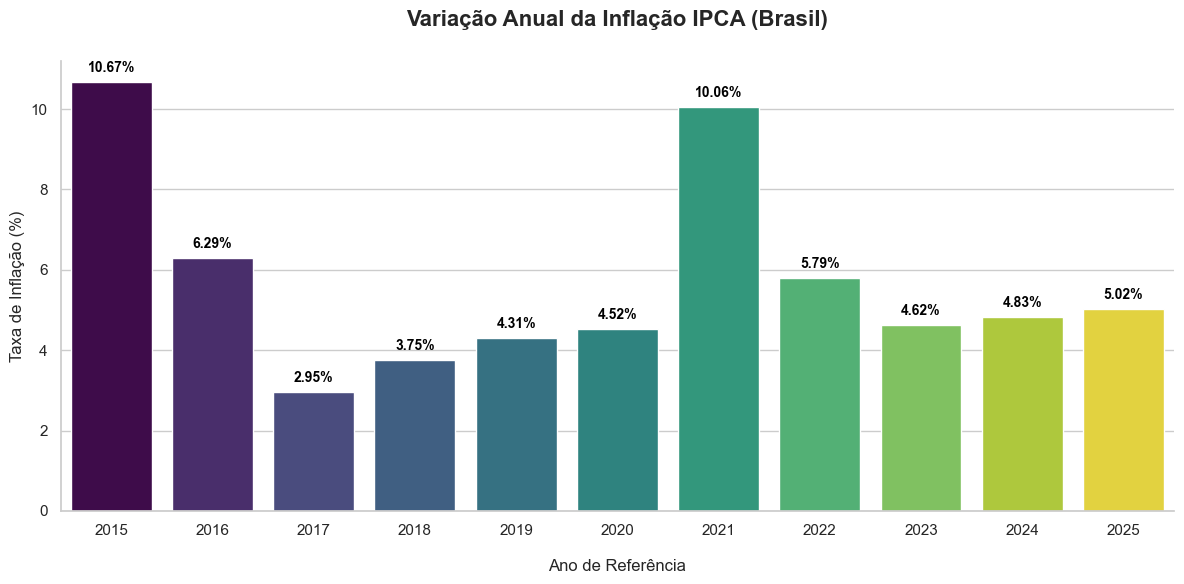

In [ ]:
class VisualizadorHistoricoIPCA:
    def __init__(self, dados_inflacao_dict: dict):
        self.df_ipca = pd.DataFrame(
            list(dados_inflacao_dict.items()), 
            columns=['Ano', 'Taxa_IPCA']
        )
        sns.set_theme(style="whitegrid")

    def plotar_evolucao_barras(self) -> None:
        plt.figure(figsize=(12, 6))

        ax = sns.barplot(
            data=self.df_ipca,
            x='Ano',
            y='Taxa_IPCA',
            palette='viridis', 
            hue='Ano',        
            legend=False       
        )

        for barra in ax.patches:
            height = barra.get_height()
            ax.annotate(
                f'{height:.2f}%', 
                (barra.get_x() + barra.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=10, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points' 
            )

        plt.title('Variação Anual da Inflação IPCA (Brasil)', fontsize=16, fontweight='bold', pad=25)
        plt.xlabel('Ano de Referência', fontsize=12, labelpad=15)
        plt.ylabel('Taxa de Inflação (%)', fontsize=12)

        plt.xticks(rotation=0) 
        sns.despine()
        plt.tight_layout()
        plt.show()


# 1. Dados 
historico_ipca_bcb = {
    2015: 10.67, 2016: 6.29, 2017: 2.95, 2018: 3.75, 2019: 4.31,
    2020: 4.52, 2021: 10.06, 2022: 5.79, 2023: 4.62, 2024: 4.83, 2025: 5.02
}

visualizador = VisualizadorHistoricoIPCA(historico_ipca_bcb)
visualizador.plotar_evolucao_barras()

#### 3.3.2 Analise do IPCA, Multiplicador de Correção em relação ao Valor

In [55]:

class CalculadoraDeInflacaoIPCA:
    def gerar_relatorio_de_fator_de_correcao(self):
        dados_bcb = {
            2015: 10.67, 2016: 6.29, 2017: 2.95, 2018: 3.75, 2019: 4.31,
            2020: 4.52, 2021: 10.06, 2022: 5.79, 2023: 4.62, 2024: 4.83, 2025: 5.02
        }
        df_ipca = pd.DataFrame(list(dados_bcb.items()), columns=['Ano', 'IPCA_Anual_Percentual'])
        
        df_ipca['Multiplicador'] = 1 + (df_ipca['IPCA_Anual_Percentual'] / 100)
        df_ipca = df_ipca.sort_values(by='Ano', ascending=False)
        
        df_ipca['Fator_Correcao'] = df_ipca['Multiplicador'].cumprod().shift(1).fillna(1.0)
        df_ipca = df_ipca.sort_values(by='Ano')
        
        # Retornando exatamente os nomes criados
        return df_ipca[['Ano', 'IPCA_Anual_Percentual', 'Fator_Correcao']] 
    
class AnalisadorDeEvolucaoRealVsNominalPrecos:
    def __init__(self, dataframe: pd.DataFrame, calculadora_ipca: CalculadoraDeInflacaoIPCA):
        self.dataframe = dataframe.copy()
        self.calculadora_ipca = calculadora_ipca
        self._garantir_coluna_ano()
        
    def _garantir_coluna_ano(self):
        if 'Ano' not in self.dataframe.columns:
            self.dataframe['Data da Coleta'] = pd.to_datetime(self.dataframe['Data da Coleta'], errors='coerce')
            self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year
            
    def processar_relatorio_evolucao_do_produto(self, nome_do_produto: str, df_inflacao: pd.DataFrame):
        dados_do_produto = self.dataframe[self.dataframe['Produto'] == nome_do_produto]
        
        estatatisticas_nominais = (
            dados_do_produto
            .groupby('Ano')['Valor de Venda']
            .agg(Media_Nominal='mean')
            .reset_index()
        )
        
        tabela_ipca_correcao = pd.merge(estatatisticas_nominais, df_inflacao, on='Ano', how='left')
        
        # Multiplicando 
        tabela_ipca_correcao['Media_Real'] = (tabela_ipca_correcao['Media_Nominal'] * tabela_ipca_correcao['Fator_Correcao']).round(2)
        
        # Renomear colunas
        tabela_ipca_correcao_renomeada = tabela_ipca_correcao.rename(columns={
            'Media_Nominal': 'Preço na Bomba da Época (R$)',
            'Media_Real': 'Preço Equivalente Hoje (R$)',
            'IPCA_Anual_Percentual': 'Inflação do Ano (%)',
            'Fator_Correcao': 'Multiplicador de Correção'
        }).set_index('Ano').round(2)
        
        return tabela_ipca_correcao_renomeada
    
    def exibir_relatorio_ajustados_pela_inflacao(self):
        print("\n" + "-"*70)
        print(" 💰 ANÁLISE DE PODER DE COMPRA: PREÇO NOMINAL VS PREÇO REAL (AJUSTADO IPCA) 💰")
        print("-" * 70 + "\n")
        
        dataFrame_inflacao = self.calculadora_ipca.gerar_relatorio_de_fator_de_correcao()
        produtos_unicos_ordenados = sorted(self.dataframe['Produto'].dropna().unique())
        
        for produto in produtos_unicos_ordenados:
            print(f"\n ⛽ PRODUTO: {produto}\n")
            relatorio_final = self.processar_relatorio_evolucao_do_produto(produto, dataFrame_inflacao)
            display(relatorio_final)
            
calculadora_ipca = CalculadoraDeInflacaoIPCA()
analisador_evolucao_real_vs_nominal = AnalisadorDeEvolucaoRealVsNominalPrecos(dataframe_final, calculadora_ipca)
analisador_evolucao_real_vs_nominal.exibir_relatorio_ajustados_pela_inflacao()


----------------------------------------------------------------------
 💰 ANÁLISE DE PODER DE COMPRA: PREÇO NOMINAL VS PREÇO REAL (AJUSTADO IPCA) 💰
----------------------------------------------------------------------


 ⛽ PRODUTO: DIESEL



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.81,10.67,1.66,4.66
2016.0,3.02,6.29,1.56,4.71
2017.0,3.09,2.95,1.52,4.69
2018.0,3.50,3.75,1.46,5.11
2019.0,3.59,4.31,1.40,5.04
2020.0,3.43,4.52,1.34,4.60
2021.0,4.66,10.06,1.22,5.68
2022.0,6.57,5.79,1.15,7.56
2023.0,5.76,4.62,1.10,6.34



 ⛽ PRODUTO: DIESEL S10



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.96,10.67,1.66,4.91
2016.0,3.15,6.29,1.56,4.92
2017.0,3.21,2.95,1.52,4.87
2018.0,3.59,3.75,1.46,5.25
2019.0,3.68,4.31,1.40,5.16
2020.0,3.52,4.52,1.34,4.72
2021.0,4.71,10.06,1.22,5.73
2022.0,6.66,5.79,1.15,7.67
2023.0,5.86,4.62,1.10,6.45



 ⛽ PRODUTO: ETANOL



...

,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,3.35,10.67,1.66,5.55
2016.0,3.72,6.29,1.56,5.81
2017.0,3.76,2.95,1.52,5.71
2018.0,4.45,3.75,1.46,6.50
2019.0,4.42,4.31,1.40,6.19
2020.0,4.29,4.52,1.34,5.75
2021.0,5.82,10.06,1.22,7.09
2022.0,6.29,5.79,1.15,7.24
2023.0,5.54,4.62,1.10,6.10



 ⛽ PRODUTO: GASOLINA ADITIVADA



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2020.0,4.57,4.52,1.34,6.13
2021.0,5.97,10.06,1.22,7.27
2022.0,6.44,5.79,1.15,7.42
2023.0,5.73,4.62,1.10,6.30
2024.0,6.10,4.83,1.05,6.41
2025.0,6.45,5.02,1.00,6.45



 ⛽ PRODUTO: GNV



,Preço na Bomba da Época (R$),Inflação do Ano (%),Multiplicador de Correção,Preço Equivalente Hoje (R$)
Ano,,,,
2015.0,2.03,10.67,1.66,3.37
2016.0,2.26,6.29,1.56,3.53
2017.0,2.35,2.95,1.52,3.57
2018.0,2.72,3.75,1.46,3.97
2019.0,3.21,4.31,1.40,4.50
2020.0,3.17,4.52,1.34,4.25
2021.0,3.86,10.06,1.22,4.70
2022.0,5.03,5.79,1.15,5.80
2023.0,4.66,4.62,1.10,5.13


## 4. Análise de Distribuições e Visualizações

*Criar gráficos para visualizar o comportamento dos dados (evitar gráfico pizza)*

## 5. Identificação de Problemas nos Dados

Durante a análise exploratória dos dados, foram identificados alguns desafios e limitações que podem impactar tanto a interpretação dos resultados quanto o desempenho de modelos preditivos.

#### 5.1.0 Desbalancemaneto de Dados

Observa-se um desbalanceamento significativo na distribuição dos dados, tanto em relação aos tipos de combustível quanto às regiões geográficas:

* **Tipo de combustível**: A categoria gasolina aditivada só passa a aparecer com frequência a partir de 2020, o que pode comprometer análises temporais e gerar viés em modelos que considerem períodos anteriores.

* **Distribuição regional**: Há uma forte concentração de dados na região Sudeste, enquanto regiões como Norte e Centro-Oeste possuem menor representatividade:

In [56]:
analisador_regional.gerar_relatorio_completo_distribuidor_regional()


FREQUÊNCIA ABSOLUTA REGIONAL:


,Quantidade de Registros
Região,
SE,4805520
NE,1948525
S,1671048
CO,842951
N,612690


 

FREQUÊNCIA PERCENTUAL REGIONAL:


,Percentual (%)
Região,
SE,48.64
NE,19.72
S,16.91
CO,8.53
N,6.20


* Esse desbalanceamento pode levar o modelo a aprender padrões mais representativos de determinadas regiões, reduzindo sua capacidade de generalização.

#### 5.2.0 Ausência de Correção Monetária

Os valores de venda dos combustíveis não estão ajustados pela inflação ao longo do tempo.

Considerando que o período analisado (2015–2025) inclui variações econômicas significativas, a comparação direta dos preços pode levar a interpretações equivocadas. Idealmente, os valores deveriam ser corrigidos por índices inflacionários (como IPCA) para permitir análises mais consistentes.

#### 5.3.0 Presença de Outliers e Eventos Exógenos

Foram identificados valores atípicos (outliers) que não necessariamente representam erros, mas sim reflexos de eventos econômicos e sociais relevantes, tais como:

* **2016**: Crise econômica no Brasil
* **2018**: Greve dos caminhoneiros
* **2020**: Pandemia de COVID-19
* **2022**: Alta global nos preços dos combustíveis

Esses eventos geram picos ou quedas abruptas nos preços, podendo impactar negativamente modelos preditivos caso não sejam tratados adequadamente.

#### 5.4.0 Granularidade Temporal e Espacial

Os dados são coletados semanalmente e em diferentes municípios, o que pode gerar:

* Variações locais significativas (diferenças entre cidades);
* Ruídos temporais devido à frequência de coleta;
* Dificuldade em capturar tendências mais suaves sem algum tipo de agregação (ex.: média mensal).

#### 5.5.0 Dados Ausentes

O dataset apresenta valores ausentes em algumas colunas. No entanto:

* A maioria dos dados faltantes está associada a variáveis de menor relevância (ex.: campos complementares);
* As variáveis principais para modelagem (como preço, data e localização) apresentam boa completude.

Mesmo assim, é importante avaliar cuidadosamente o impacto desses dados ausentes antes de aplicar técnicas de imputação ou remoção.


------------------------------------------------------------
 ANÁLISE DE QUALIDADE: VALORES AUSENTES (NULOS)
------------------------------------------------------------



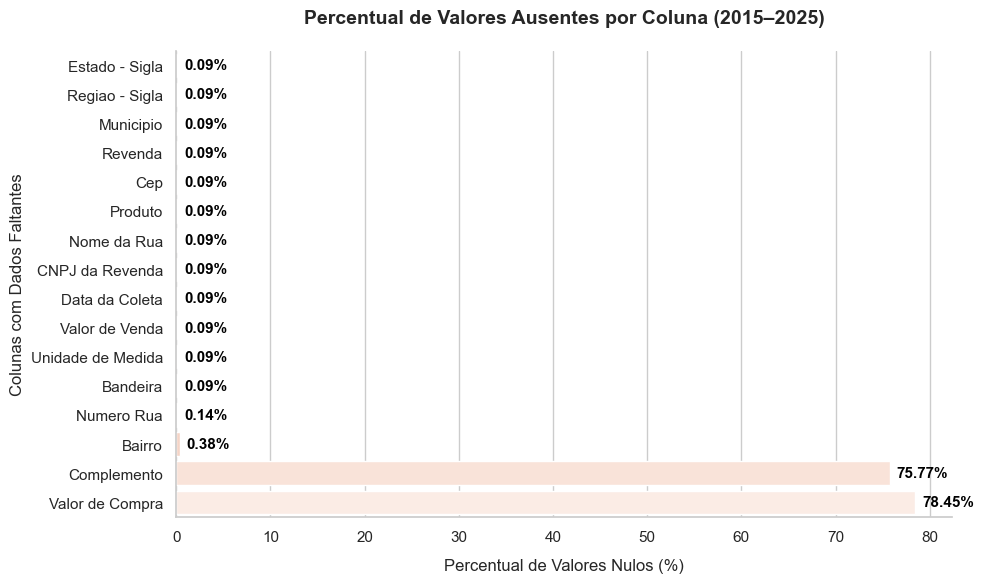

In [57]:
class AnalisadorDeQualidadeDeDados:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        sns.set_theme(style="whitegrid")

    def calcular_percentual_de_valores_ausentes(self):
        percentuais_nulos = (self.dataframe.isnull().sum() / len(self.dataframe)) * 100
        
        percentuais_nulos = percentuais_nulos[percentuais_nulos > 0].sort_values(ascending=False).round(2)
        
        return percentuais_nulos

    def plotar_grafico_de_valores_ausentes(self, percentuais_nulos: pd.Series):
        print("\n" + "-"*60)
        print(" ANÁLISE DE QUALIDADE: VALORES AUSENTES (NULOS)")
        print("-"*60 + "\n")

        if percentuais_nulos.empty:
            print("✅ Excelente! Não há valores ausentes no dataset.")
            return

        plt.figure(figsize=(10, 6))

        dados_para_plot = percentuais_nulos.sort_values(ascending=True)
        
        ax = sns.barplot(
            x=dados_para_plot.values, 
            y=dados_para_plot.index,
            palette='Reds_r',
            hue=dados_para_plot.index,
            legend=False
        )

        for barra in ax.patches:
            ax.annotate(
                f'{barra.get_width():.2f}%', 
                (barra.get_width(), barra.get_y() + barra.get_height() / 2.),
                ha='left', va='center',
                fontsize=11, color='black', fontweight='bold',
                xytext=(5, 0), textcoords='offset points' # Desloca o texto um pouco para a direita
            )

        plt.title('Percentual de Valores Ausentes por Coluna (2015–2025)', fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Percentual de Valores Nulos (%)', fontsize=12, labelpad=10)
        plt.ylabel('Colunas com Dados Faltantes', fontsize=12)

        sns.despine()
        plt.tight_layout()
        plt.show()

    def gerar_relatorio_de_qualidade_de_dados(self):
        dados_calculados = self.calcular_percentual_de_valores_ausentes()
        self.plotar_grafico_de_valores_ausentes(dados_calculados)


analisador_qualidade = AnalisadorDeQualidadeDeDados(dataframe_final)
analisador_qualidade.gerar_relatorio_de_qualidade_de_dados()

#### 5.5.0 Valores Ausentes na Varável Temporal

Foi identificado um volume significativo de valores ausentes na variável Data da Coleta.

Observa-se que esses registros não estão associados a nenhum período específico, o que impossibilita sua distribuição ao longo do tempo e compromete análises baseadas em séries temporais.

Dessa forma:

* Esses dados não podem ser utilizados em análises temporais;
* É necessário avaliar estratégias de tratamento, como:

    * Remoção das instâncias;
    * Ou utilização apenas em análises não temporais.

A ausência da variável temporal representa uma limitação relevante do dataset, impactando diretamente a modelagem preditiva baseada em séries temporais.

#### 5.6.0 Rankin de Valores Ausentes por Coluna

Abaixo está o ranking das colunas com maior quantidade de dados faltantes, permitindo identificar quais variáveis demandam maior atenção durante o processo de tratamento e preparação dos dados.

In [58]:
import pandas as pd
from IPython.display import display

class AnalisadorTabularDeValoresAusentes:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe

    def calcular_estatisticas_de_dados_ausentes(self):
        total_de_linhas = len(self.dataframe)
        contagem_de_nulos = self.dataframe.isnull().sum()
        percentual_de_nulos = (contagem_de_nulos / total_de_linhas) * 100

        tabela_ausentes = pd.DataFrame({
            'Valores Faltantes (Qtd)': contagem_de_nulos,
            'Percentual (%)': percentual_de_nulos
        })

        tabela_ausentes = tabela_ausentes[tabela_ausentes['Valores Faltantes (Qtd)'] > 0]
        tabela_ausentes = tabela_ausentes.drop(index='Ano', errors='ignore')

        tabela_ausentes = tabela_ausentes.sort_values(by='Valores Faltantes (Qtd)', ascending=False)
        tabela_ausentes['Percentual (%)'] = tabela_ausentes['Percentual (%)'].round(2)

        return tabela_ausentes

    def exibir_relatorio_tabular(self, tabela_ausentes: pd.DataFrame):
        print("\n" + "-"*60)
        print("TABELA DETALHADA: VALORES AUSENTES POR COLUNA")
        print("-"*60 + "\n")

        if tabela_ausentes.empty:
            print("✅ O dataset está íntegro. Nenhuma das colunas originais possui valores nulos.")
        else:
            display(tabela_ausentes)

    def gerar_relatorio_completo_de_nulos(self):
        tabela_calculada = self.calcular_estatisticas_de_dados_ausentes()
        
        self.exibir_relatorio_tabular(tabela_calculada)

analisador_tabular_nulos = AnalisadorTabularDeValoresAusentes(dataframe_final)
analisador_tabular_nulos.gerar_relatorio_completo_de_nulos()


------------------------------------------------------------
TABELA DETALHADA: VALORES AUSENTES POR COLUNA
------------------------------------------------------------



,Valores Faltantes (Qtd),Percentual (%)
Valor de Compra,7758881,78.45
Complemento,7493123,75.77
Bairro,37430,0.38
Numero Rua,13925,0.14
Revenda,9114,0.09
Municipio,9114,0.09
Regiao - Sigla,9114,0.09
Estado - Sigla,9114,0.09
CNPJ da Revenda,9114,0.09
Nome da Rua,9114,0.09


# Conclusão


Conclusão
Ao longo deste notebook, foram realizadas etapas de análise exploratória e identificação de padrões relevantes no comportamento dos preços de combustíveis no Brasil.

A partir dos resultados obtidos, foi possível compreender melhor a estrutura dos dados, suas limitações e os principais desafios envolvidos, como a presença de valores ausentes e desbalanceamentos.

Essas análises são fundamentais para orientar as próximas etapas do projeto, especialmente no desenvolvimento de modelos preditivos mais robustos e confiáveis.

### Próximos passos

* Tratamento de dados faltantes
* Engenharia de features
* Construção e avaliação de modelos preditivos
* Análise de desempenho e validação